In [16]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Input

In [17]:
from keras.callbacks import EarlyStopping
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [18]:
X, y = make_circles(n_samples=200, noise=0.1, random_state=1)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)

In [20]:
print(X, y)

[[-0.90012442 -0.5158365 ]
 [-0.76025757  0.76169256]
 [-0.52892981  0.89165206]
 [ 0.72865626  0.02235589]
 [ 0.35089517 -0.61320606]
 [ 0.83644797 -0.09286563]
 [ 0.90573966 -0.24860163]
 [ 1.20710374  0.23630155]
 [-0.28110925  0.99965858]
 [-0.0944606  -0.75547401]
 [-0.38045819 -0.70644158]
 [ 0.42898254  0.92445407]
 [ 0.86125836  0.42394051]
 [ 0.85219796 -0.51900686]
 [ 0.62676554  0.45914376]
 [ 0.48207171  0.58219714]
 [-0.60811099 -0.50589088]
 [-0.59717296  0.79203959]
 [-0.56405365  0.67020536]
 [-0.80519966 -0.31463531]
 [-1.01425119 -0.0336727 ]
 [ 0.54663306  0.82437463]
 [-0.90649326  0.38366388]
 [ 0.989149   -0.50318032]
 [-0.28506809  0.94109829]
 [-0.70744947 -0.38768938]
 [-0.48152669  0.65131462]
 [-0.10966666  0.99132237]
 [ 0.70520189 -0.26629758]
 [-0.16725104  0.99261075]
 [-1.06564298  0.14944543]
 [-0.52459045 -0.53885183]
 [ 0.7560018  -0.22913562]
 [ 0.09135109 -0.7036046 ]
 [ 0.19048108 -0.77665313]
 [ 0.9739273  -0.37117888]
 [-0.07083866 -0.79420584]
 

<Axes: >

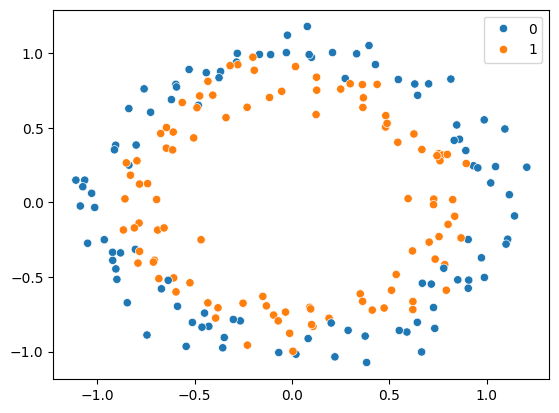

In [21]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [22]:
model = Sequential()

In [23]:
model.add(Input(shape=(2,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [24]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

Normal training without early stoping

In [26]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=3500, verbose=0)

In [47]:
from sklearn.metrics import r2_score

In [48]:
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)*100

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


58.988165855407715

In [32]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

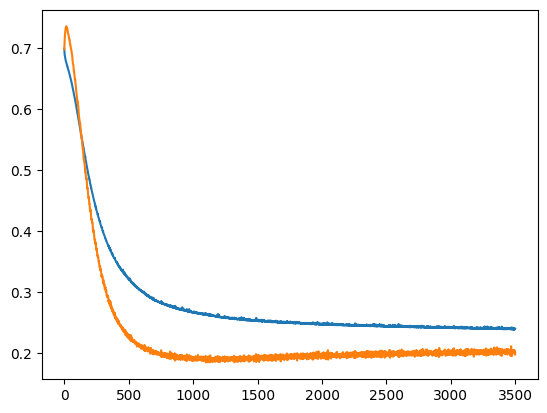

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

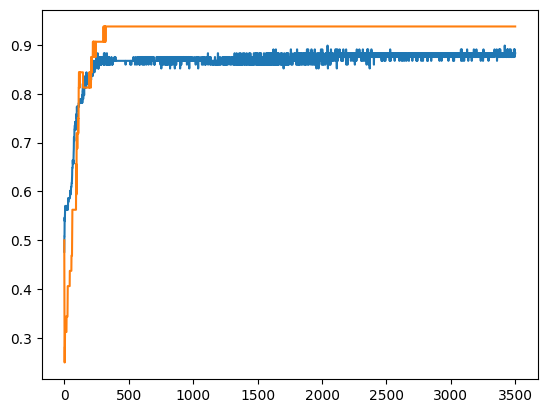

In [34]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

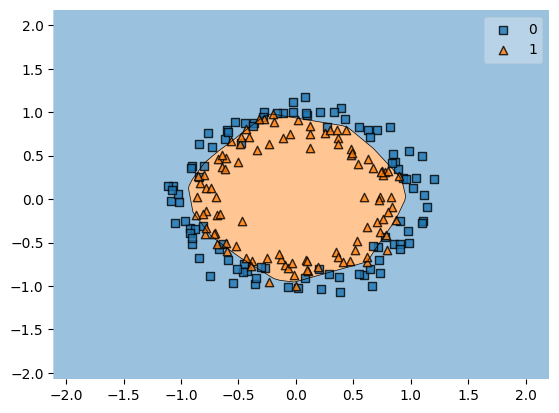

In [35]:
plot_decision_regions(X, y, clf=model)

With early stoping

In [40]:
CALLBACK = EarlyStopping(
monitor='val_loss',
min_delta=0.00001,
patience=20,
verbose=1,
mode='auto',
baseline=None,
restore_best_weights=False
)

In [41]:
model_with_early_stpping = Sequential()

In [42]:
model_with_early_stpping.add(Input(shape=(2,)))
model_with_early_stpping.add(Dense(256, activation='relu'))
model_with_early_stpping.add(Dense(1, activation='sigmoid'))


In [43]:
model_with_early_stpping.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [44]:
history_of_early_stoping = model_with_early_stpping.fit(X_train, y_train, epochs=3500, validation_split=0.2, callbacks=CALLBACK)

Epoch 1/3500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.5000 - loss: 0.6996 - val_accuracy: 0.5312 - val_loss: 0.6940
Epoch 2/3500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5078 - loss: 0.6959 - val_accuracy: 0.3750 - val_loss: 0.6987
Epoch 3/3500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5156 - loss: 0.6920 - val_accuracy: 0.3125 - val_loss: 0.7046
Epoch 4/3500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5469 - loss: 0.6891 - val_accuracy: 0.3125 - val_loss: 0.7097
Epoch 5/3500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5625 - loss: 0.6869 - val_accuracy: 0.3438 - val_loss: 0.7137
Epoch 6/3500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5625 - loss: 0.6849 - val_accuracy: 0.3438 - val_loss: 0.7175
Epoch 7/3500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5625 - loss: 0.6835 - val_accuracy: 0.3438 - val_loss: 0.7207
Epoch 8/3500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6825 - val_accuracy: 0.3750 - 

In [49]:
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)*100

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


58.988165855407715

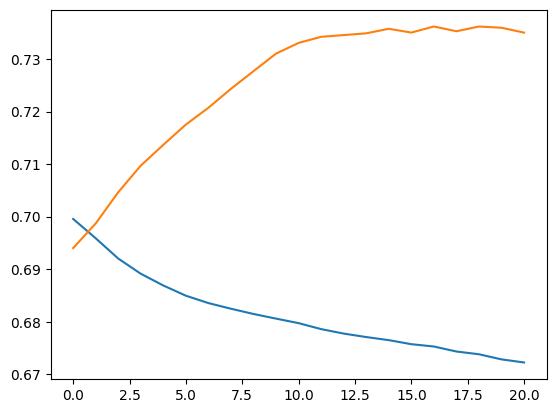

In [45]:
plt.plot(history_of_early_stoping.history['loss'])
plt.plot(history_of_early_stoping.history['val_loss'])
plt.show()

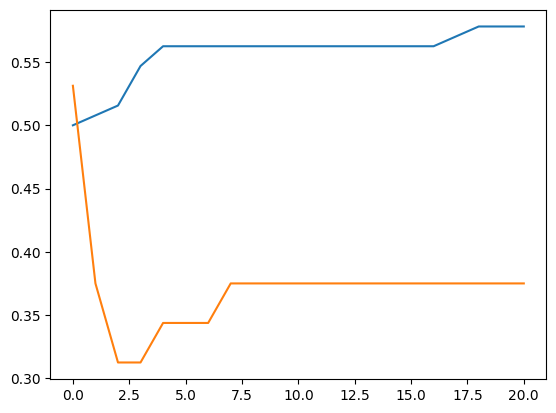

In [46]:
plt.plot(history_of_early_stoping.history['accuracy'])
plt.plot(history_of_early_stoping.history['val_accuracy'])
plt.show()